# AI Keyword Sweep and Demand-Side Analysis (Notebook 04)

Deterministic regex sweep of the 5M Adzuna `production_5m` sample for
employer-side AI language, plus the demand-side analysis layer built on top.
Companion to Notebook 03 (`03_topline_report_analysis.ipynb`); Notebook 03 is
not modified. The spine is rebuilt from persisted inputs so this notebook
does not depend on Notebook 03's kernel state.

This notebook is **demand-side language**, not adoption. Aggregating mention
rates does not turn them into an adoption measure.

Pipeline at a glance:

1. Load TOML dictionary (six families, version-stamped).
2. Rebuild `ad_primary` from persisted parquet + adzuna.duckdb (same
   `ARG_MAX` SQL Notebook 03 uses, extended with the text columns).
3. Apply Notebook 03's five-label quadrant; assert per-ad quadrant tallies
   reproduce Notebook 03's `quadrant_counts.csv`.
4. Run DuckDB ↔ Python `re` equivalence check on the unit-test cases.
5. Full per-ad regex sweep inside DuckDB. Writes
   `ai_keyword_hits_v1.parquet`.
6. Build nine analysis tables (rates per 10,000, always with n).
7. Eight QC samples + the length-confound inspection.
8. Write `topline_keyword_numbers.json`, manifest, and the completion
   `*_meta.json` (last).

In [1]:
import hashlib
import json
import re
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import duckdb
import matplotlib
try:
    from IPython import get_ipython
    _ipy = get_ipython()
    if _ipy is None:
        matplotlib.use('Agg')
    else:
        _ipy.run_line_magic('matplotlib', 'inline')
except (ImportError, AttributeError):
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'store').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# Make src/analysis importable from inside the notebook.
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from analysis.keyword_matcher import load_dictionary  # noqa: E402

# Inputs
AD_EXPOSURE_PATH = ROOT / "store/pipeline/production_5m/compute_job_ad_exposure/ad_exposure.parquet"
RERANK_PATH      = ROOT / "store/pipeline/production_5m/rerank_candidates/reranked_matches.parquet"
ADZUNA_DB_PATH   = ROOT / "store/inputs/adzuna.duckdb"
ONET_DATA_PATH   = ROOT / "store/inputs/onet/db_30_0_text/Occupation Data.txt"
GEO_LAD_PATH     = ROOT / "store/outputs/production_5m/production_5m/geo_lad.csv"
ONET_SCORES_PATH = ROOT / "store/outputs/onet_exposure_scores/scores.csv"
TOPLINE_JSON_PATH = ROOT / "store/analysis/report_pack/topline_numbers.json"
QUAD_COUNTS_PATH  = ROOT / "store/analysis/tables/quadrant_counts.csv"
DICT_PATH = ROOT / "config/ai_keyword_sweep/keyword_families_v1.toml"

# Outputs
SWEEP_DIR  = ROOT / "store/pipeline/production_5m/ai_keyword_sweep"
HITS_PATH  = SWEEP_DIR / "ai_keyword_hits_v1.parquet"
# (ad_id, title, description) for the 5M sweep population, extracted once
# from adz.ads (which is 169GB and unindexed) so QC audits can fetch text
# in O(rows-fetched) rather than O(adz.ads-size).
AD_TEXT_PATH = SWEEP_DIR / "ad_text_v1.parquet"
ANALYSIS_DIR = SWEEP_DIR / "analysis"
AUDIT_DIR  = SWEEP_DIR / "audit_samples"
FIG_DIR    = SWEEP_DIR / "figures"
MANIFEST_PATH = SWEEP_DIR / "keyword_sweep_manifest.csv"
META_PATH     = SWEEP_DIR / "ai_keyword_sweep_v1_meta.json"
TOPLINE_KEYWORD_PATH = SWEEP_DIR / "analysis/topline_keyword_numbers.json"
for p in (SWEEP_DIR, ANALYSIS_DIR, AUDIT_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

# Plot conventions mirror Notebook 03
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
PRIMARY   = '#2C3E50'
SECONDARY = '#2980B9'
ACCENT    = '#E74C3C'
GREEN     = '#27AE60'
ORANGE    = '#F39C12'
PURPLE    = '#9B59B6'
GREY_MED  = '#95A5A6'
GREY_LIGHT = '#ECF0F1'

# Notebook 03's major-group map; reused so groupings line up.
ONET_MAJOR_NAMES = {
    11: "Management", 13: "Business & Financial", 15: "Computer & Mathematical",
    17: "Architecture & Engineering", 19: "Life, Physical & Social Science",
    21: "Community & Social Service", 23: "Legal", 25: "Educational Instruction",
    27: "Arts, Design, Entertainment", 29: "Healthcare Practitioners",
    31: "Healthcare Support", 33: "Protective Service", 35: "Food Preparation & Serving",
    37: "Building & Grounds Cleaning", 39: "Personal Care & Service", 41: "Sales",
    43: "Office & Administrative", 45: "Farming, Fishing, Forestry",
    47: "Construction & Extraction", 49: "Installation, Maintenance, Repair",
    51: "Production", 53: "Transportation & Material Moving",
}

# topline_keyword_numbers.json accumulator; written at the end.
topline_keyword: dict = {
    "metadata": {
        "run_name": "production_5m",
        "executed_at": datetime.now(timezone.utc).isoformat(timespec='seconds'),
        "dictionary_path": str(DICT_PATH.relative_to(ROOT)),
        "inputs": {
            "ad_exposure": str(AD_EXPOSURE_PATH.relative_to(ROOT)),
            "rerank":      str(RERANK_PATH.relative_to(ROOT)),
            "adzuna_db":   str(ADZUNA_DB_PATH.relative_to(ROOT)),
            "topline_numbers_v1": str(TOPLINE_JSON_PATH.relative_to(ROOT)),
            "quadrant_counts_v1": str(QUAD_COUNTS_PATH.relative_to(ROOT)),
        },
    },
}

for p in (AD_EXPOSURE_PATH, RERANK_PATH, ADZUNA_DB_PATH,
          TOPLINE_JSON_PATH, QUAD_COUNTS_PATH, DICT_PATH):
    assert p.exists(), f"missing required input: {p}"

print(f"ROOT = {ROOT}")
print(f"SWEEP_DIR = {SWEEP_DIR.relative_to(ROOT)}")

ROOT = /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2
SWEEP_DIR = store/pipeline/production_5m/ai_keyword_sweep


## §2 — Load dictionary

Loaded once and passed by reference to DuckDB. The TOML is the source of
truth; every output is stamped with `dictionary_version`.

In [2]:
d = load_dictionary(DICT_PATH)
DICTIONARY_VERSION = d.version
FAMILY_KEYS = [
    "generic_ai", "ai_tool_use", "machine_learning",
    "generative_ai", "ai_ops_governance", "chatbot_automation",
]
assert set(d.families.keys()) == set(FAMILY_KEYS), \
    f"family-set mismatch: dictionary={set(d.families.keys())}, expected={set(FAMILY_KEYS)}"

n_terms_by_fam = {fk: sum(1 for t in d.terms if t.family == fk) for fk in FAMILY_KEYS}
print(f"dictionary_version = {DICTIONARY_VERSION}")
print(f"total terms        = {len(d.terms)}")
print("per-family term count:")
for fk in FAMILY_KEYS:
    print(f"  {fk:22s} {n_terms_by_fam[fk]:3d}  ({d.families[fk]})")

topline_keyword["metadata"]["dictionary_version"] = DICTIONARY_VERSION
topline_keyword["metadata"]["n_terms"] = len(d.terms)
topline_keyword["metadata"]["n_terms_by_family"] = n_terms_by_fam

dictionary_version = v1
total terms        = 108
per-family term count:
  generic_ai               7  (Generic AI)
  ai_tool_use             20  (AI tool use & assistive phrasing)
  machine_learning        29  (Machine learning)
  generative_ai           36  (Generative AI & LLMs)
  ai_ops_governance       11  (AI operations & governance)
  chatbot_automation       5  (Chatbots & AI automation)


## §3 — adz.ads schema check

Confirm `title` and `description` exist before relying on them. The spec
leaves this open because the column names are unverified at brief time.

In [3]:
con = duckdb.connect(":memory:")
con.execute(f"ATTACH '{ADZUNA_DB_PATH}' AS adz (READ_ONLY)")
con.execute(f"CREATE VIEW ad_exp AS SELECT * FROM read_parquet('{AD_EXPOSURE_PATH}')")
con.execute(f"CREATE VIEW rerank AS SELECT * FROM read_parquet('{RERANK_PATH}')")

schema_rows = con.execute("DESCRIBE adz.ads").fetchall()
schema_df = pd.DataFrame(schema_rows, columns=['column_name', 'column_type', 'null', 'key', 'default', 'extra'])
schema_df = schema_df[['column_name', 'column_type']]
print(f"adz.ads has {len(schema_df)} columns")
print(schema_df.to_string(index=False))
assert 'title' in schema_df['column_name'].values, "adz.ads is missing `title`"
assert 'description' in schema_df['column_name'].values, "adz.ads is missing `description`"
assert 'id' in schema_df['column_name'].values, "adz.ads is missing `id` (join key)"

adz.ads has 33 columns
           column_name column_type
                    id      BIGINT
                  year     INTEGER
                 month     INTEGER
          date_created     VARCHAR
                 title     VARCHAR
           description     VARCHAR
          location_raw     VARCHAR
               geo_lat     VARCHAR
               geo_lng     VARCHAR
               LAD22CD     VARCHAR
               LAD22NM     VARCHAR
               LAD24CD     VARCHAR
           category_id      BIGINT
         category_name     VARCHAR
           company_raw     VARCHAR
            company_id      DOUBLE
    normalised_company     VARCHAR
            salary_min      DOUBLE
            salary_max      DOUBLE
       salary_currency     VARCHAR
      salary_predicted      DOUBLE
            salary_raw     VARCHAR
         contract_type     VARCHAR
         contract_time     VARCHAR
   soc2020_major_group     VARCHAR
soc2020_submajor_group     VARCHAR
   soc2020_minor_group     VARCH

## §4 — Read ad_thresholds

Take the canonical quadrant thresholds from Notebook 03's
`topline_numbers.json` so the quadrant equality check is exact.

In [4]:
with open(TOPLINE_JSON_PATH) as f:
    topline_v1 = json.load(f)
AD_THR = topline_v1["quadrants"]["ad_thresholds"]
print("ad_thresholds (Notebook 03):")
for k, v in AD_THR.items():
    print(f"  {k:8s} {v:.6f}")
# n_ads_total etc.
N_ADS_TOTAL = topline_v1["sampling"]["n_ads_total"]
N_ADS_2022  = topline_v1["sampling"]["n_ads_2022"]
N_ADS_2025  = topline_v1["sampling"]["n_ads_2025"]
print(f"\nNotebook-03 corpus: n_ads_total={N_ADS_TOTAL:,}  2022={N_ADS_2022:,}  2025={N_ADS_2025:,}")

ad_thresholds (Notebook 03):
  exp_q1   0.288866
  exp_q3   0.490173
  pres_q1  0.492467
  pres_q3  0.553994

Notebook-03 corpus: n_ads_total=4,997,227  2022=3,285,356  2025=1,711,871


## §5 — Rebuild `ad_primary`

Notebook 03's exact `ARG_MAX` SQL, no year filter (the corpus is already
2022+2025 only — `N_ADS_2022 + N_ADS_2025 == N_ADS_TOTAL`). Text columns
stay on `adz.ads`; the spine carries only the structured columns. The
regex sweep query joins to `adz.ads` itself and streams the text.

In [5]:
t0 = time.time()
con.execute("""
  CREATE OR REPLACE TABLE ad_primary AS
  WITH top_match AS (
    SELECT ad_id, ARG_MAX(onet_code, rerank_score) AS primary_onet
    FROM rerank GROUP BY ad_id
  )
  SELECT
    e.ad_id,
    e.n_matches,
    e.task_exposure_mean,
    e.task_exposure_bt_mean,
    e.felten_score,
    e.presence_composite,
    t.primary_onet,
    SUBSTR(t.primary_onet, 1, 2)::INTEGER AS primary_major_code,
    a.year,
    a.LAD22CD
  FROM ad_exp e
  LEFT JOIN top_match t ON e.ad_id = t.ad_id
  LEFT JOIN adz.ads a   ON e.ad_id = a.id
  WHERE e.n_matches > 0
    AND t.primary_onet IS NOT NULL
""")
elapsed_spine = time.time() - t0
n_primary = con.execute("SELECT COUNT(*) FROM ad_primary").fetchone()[0]
by_year = con.execute("""
  SELECT year, COUNT(*) AS n FROM ad_primary GROUP BY year ORDER BY year
""").fetchdf()
print(f"ad_primary built in {elapsed_spine:.1f}s: {n_primary:,} rows")
print(by_year.to_string(index=False))

assert n_primary == N_ADS_TOTAL, (
    f"ad_primary row count {n_primary:,} does not match topline_numbers.json "
    f"sampling.n_ads_total {N_ADS_TOTAL:,}"
)
by_year_dict = {int(r['year']): int(r['n']) for _, r in by_year.iterrows()}
assert by_year_dict.get(2022) == N_ADS_2022, \
    f"2022 mismatch: {by_year_dict.get(2022)} vs {N_ADS_2022}"
assert by_year_dict.get(2025) == N_ADS_2025, \
    f"2025 mismatch: {by_year_dict.get(2025)} vs {N_ADS_2025}"
print("✓ spine row counts match Notebook 03")

topline_keyword["spine"] = {
    "n_ads_total": int(n_primary),
    "n_ads_2022":  int(by_year_dict.get(2022, 0)),
    "n_ads_2025":  int(by_year_dict.get(2025, 0)),
    "build_seconds": round(elapsed_spine, 2),
}

ad_primary built in 1.3s: 4,997,227 rows
 year       n
 2022 3285356
 2025 1711871
✓ spine row counts match Notebook 03


## §6 — Quadrant labels and equality QC

Apply Notebook 03's five-label scheme using the same thresholds. The per-ad
tally must reproduce Notebook 03's `quadrant_counts.csv` row for the ad
population — same thresholds, same population, so the counts are equality
by construction. A mismatch means the spine or thresholds have drifted.

In [6]:
con.execute(f"""
  ALTER TABLE ad_primary ADD COLUMN quadrant VARCHAR;
""")
con.execute(f"""
  UPDATE ad_primary SET quadrant = CASE
    WHEN task_exposure_mean >= {AD_THR['exp_q3']} AND presence_composite <= {AD_THR['pres_q1']} THEN 'vulnerable'
    WHEN task_exposure_mean >= {AD_THR['exp_q3']} AND presence_composite >= {AD_THR['pres_q3']} THEN 'augmented'
    WHEN task_exposure_mean <= {AD_THR['exp_q1']} AND presence_composite >= {AD_THR['pres_q3']} THEN 'resilient'
    WHEN task_exposure_mean <= {AD_THR['exp_q1']} AND presence_composite <= {AD_THR['pres_q1']} THEN 'unchanged'
    ELSE 'middle'
  END
""")
quad_now = con.execute("""
  SELECT quadrant, COUNT(*) AS n FROM ad_primary
  GROUP BY quadrant ORDER BY quadrant
""").fetchdf()
print("Notebook-04 ad quadrant counts:")
print(quad_now.to_string(index=False))

# Compare to Notebook 03's quadrant_counts.csv (ad row).
# Schema: unit,total,vulnerable_n,vulnerable_pct,augmented_n,augmented_pct,
#         resilient_n,resilient_pct,unchanged_n,unchanged_pct
# `middle` is implied as total - (the four named cells).
quad_v1 = pd.read_csv(QUAD_COUNTS_PATH)
ads_row = quad_v1[quad_v1['unit'] == 'ads'].iloc[0]
print("\nNotebook-03 quadrant_counts.csv ad row:")
print(ads_row.to_string())

expected = {q: int(ads_row[f"{q}_n"]) for q in ['vulnerable', 'augmented', 'resilient', 'unchanged']}
expected['middle'] = int(ads_row['total']) - sum(expected.values())
observed = {r['quadrant']: int(r['n']) for _, r in quad_now.iterrows()}
print("\nside-by-side (observed vs expected):")
for q in ['vulnerable', 'augmented', 'resilient', 'unchanged', 'middle']:
    o = observed.get(q, 0)
    e = expected.get(q, 0)
    flag = "✓" if o == e else "✗"
    print(f"  {flag} {q:11s} obs={o:,}  exp={e:,}  diff={o - e:+d}")
assert observed == expected, "quadrant equality FAILED — spine or thresholds drifted"
print("\n✓ quadrant equality QC passed")

topline_keyword["quadrant_qc"] = {
    "thresholds": AD_THR,
    "counts": observed,
}

Notebook-04 ad quadrant counts:
  quadrant       n
 augmented  382335
    middle 3666935
 resilient   48253
 unchanged  748985
vulnerable  150719

Notebook-03 quadrant_counts.csv ad row:
unit                   ads
total              4997227
vulnerable_n        150719
vulnerable_pct    0.030161
augmented_n         382335
augmented_pct     0.076509
resilient_n          48253
resilient_pct     0.009656
unchanged_n         748985
unchanged_pct      0.14988

side-by-side (observed vs expected):
  ✓ vulnerable  obs=150,719  exp=150,719  diff=+0
  ✓ augmented   obs=382,335  exp=382,335  diff=+0
  ✓ resilient   obs=48,253  exp=48,253  diff=+0
  ✓ unchanged   obs=748,985  exp=748,985  diff=+0
  ✓ middle      obs=3,666,935  exp=3,666,935  diff=+0

✓ quadrant equality QC passed


## §7a — DuckDB ↔ Python `re` regex equivalence

Build the same `(?:term1|term2|...)` alternation for each family and
verify DuckDB's `regexp_matches` agrees with Python's `re.search` on the
unit-test fixture. If this diverges, the bulk sweep numbers are not
trustworthy.

In [7]:
FIXTURE = [
    # (text, expected_family_flags)
    ("email me at john@x.com",                {f: False for f in FAMILY_KEYS}),
    ("retail experience preferred",           {f: False for f in FAMILY_KEYS}),
    ("html and css required",                 {f: False for f in FAMILY_KEYS}),
    ("training new hires",                    {f: False for f in FAMILY_KEYS}),
    ("trail mix",                             {f: False for f in FAMILY_KEYS}),
    ("flagrant breach",                       {f: False for f in FAMILY_KEYS}),
    ("air conditioning maintenance",          {f: False for f in FAMILY_KEYS}),
    ("Looking for an AI-enabled product manager", {"ai_tool_use": True, "generic_ai": True}),
    ("Strong AI/ML background",               {"generic_ai": True, "machine_learning": True}),
    ("AI-driven decision making",             {"ai_tool_use": True, "generic_ai": True}),
    ("Senior ML Engineer needed",             {"machine_learning": True}),
    ("LLM-based application development",     {"generative_ai": True}),
    ("Experience with RAG pipeline design",   {"generative_ai": True}),
    ("A.I. tools for productivity",           {"generic_ai": True}),
    ("Familiar with ChatGPT and similar tools", {"generative_ai": True}),
    ("Machine Learning Engineer",             {"machine_learning": True}),
    ("Working knowledge of NLP",              {"machine_learning": True}),
]

equivalence_rows = []
all_equal = True
for text, expected_partial in FIXTURE:
    lo = text.lower()
    # Build per-family expected dict (default False; expected_partial overrides).
    expected = {f: expected_partial.get(f, False) for f in FAMILY_KEYS}
    # Python re
    py = {f: bool(re.search(d.family_patterns[f], lo)) for f in FAMILY_KEYS}
    # DuckDB regex
    dk_row = con.execute("""
      SELECT
        regexp_matches(?, ?) AS hit_generic_ai,
        regexp_matches(?, ?) AS hit_ai_tool_use,
        regexp_matches(?, ?) AS hit_machine_learning,
        regexp_matches(?, ?) AS hit_generative_ai,
        regexp_matches(?, ?) AS hit_ai_ops_governance,
        regexp_matches(?, ?) AS hit_chatbot_automation
    """, [
        lo, d.family_patterns["generic_ai"],
        lo, d.family_patterns["ai_tool_use"],
        lo, d.family_patterns["machine_learning"],
        lo, d.family_patterns["generative_ai"],
        lo, d.family_patterns["ai_ops_governance"],
        lo, d.family_patterns["chatbot_automation"],
    ]).fetchone()
    dk = {
        "generic_ai": dk_row[0], "ai_tool_use": dk_row[1],
        "machine_learning": dk_row[2], "generative_ai": dk_row[3],
        "ai_ops_governance": dk_row[4], "chatbot_automation": dk_row[5],
    }
    # Verify expectations hold (Python regex side) for the flags the fixture sets.
    for f, exp_val in expected_partial.items():
        if py[f] != exp_val:
            print(f"  ✗ expectation failure: {text!r} family={f} py={py[f]} expected={exp_val}")
            all_equal = False
    # Verify DuckDB == Python on every family.
    for f in FAMILY_KEYS:
        if dk[f] != py[f]:
            print(f"  ✗ DuckDB ≠ Python on {text!r} family={f} dk={dk[f]} py={py[f]}")
            all_equal = False
    equivalence_rows.append({
        "text": text,
        **{f"py_{f}": py[f] for f in FAMILY_KEYS},
        **{f"dk_{f}": dk[f] for f in FAMILY_KEYS},
    })

equivalence_df = pd.DataFrame(equivalence_rows)
equivalence_df.to_csv(ANALYSIS_DIR / "regex_equivalence.csv", index=False)
assert all_equal, "DuckDB regex equivalence failed — sweep numbers would not be trustworthy"
print(f"✓ regex equivalence: {len(FIXTURE)} fixture cases agree between DuckDB and Python re")

✓ regex equivalence: 17 fixture cases agree between DuckDB and Python re


## §7b — Full sweep

Streamed regex pass: DuckDB reads ad text in-engine, computes the family
flags and intensity count, writes parquet. Skipped if the parquet already
exists (delete it to force a re-run).

In [8]:
TXT_SQL = "lower(coalesce(a.title, '') || ' ' || coalesce(a.description, ''))"
# After the _src CTE the text column is exposed as `_txt`, so per-family
# regex tests reference `_txt` rather than the raw adz.ads columns.
HIT_SQL = ",\n      ".join(
    f"regexp_matches(_txt, '{d.family_patterns[fk]}') AS hit_{fk}"
    for fk in FAMILY_KEYS
)
N_FAMS_SQL = " + ".join(f"CASE WHEN hit_{fk} THEN 1 ELSE 0 END" for fk in FAMILY_KEYS)
UNION_PAT = d.union_pattern

if HITS_PATH.exists():
    print(f"sweep parquet already exists at {HITS_PATH} — skipping. Delete to re-run.")
    hits_size_mb = HITS_PATH.stat().st_size / 1e6
    print(f"  size = {hits_size_mb:.1f} MB")
else:
    t0 = time.time()
    sweep_sql = f"""
      COPY (
        WITH _src AS (
          SELECT
            e.ad_id,
            a.year,
            {TXT_SQL} AS _txt
          FROM ad_exp e
          JOIN adz.ads a ON e.ad_id = a.id
          WHERE e.n_matches > 0
            AND a.year IN (2022, 2025)
        ),
        _hits AS (
          SELECT
            ad_id,
            year,
            length(_txt) AS n_chars,
            array_length(regexp_split_to_array(_txt, '\\s+')) AS n_tokens,
            len(regexp_extract_all(_txt, '{UNION_PAT}')) AS n_total_matches,
            {HIT_SQL}
          FROM _src
        )
        SELECT
          ad_id,
          year,
          n_chars,
          n_tokens,
          n_total_matches,
          hit_generic_ai,
          hit_ai_tool_use,
          hit_machine_learning,
          hit_generative_ai,
          hit_ai_ops_governance,
          hit_chatbot_automation,
          ({N_FAMS_SQL}) AS n_families_hit,
          (hit_generic_ai OR hit_ai_tool_use OR hit_machine_learning OR
           hit_generative_ai OR hit_ai_ops_governance OR hit_chatbot_automation)
            AS any_ai_hit,
          hit_generative_ai AS generative_ai_hit,
          '{DICTIONARY_VERSION}' AS dictionary_version
        FROM _hits
      ) TO '{HITS_PATH}' (FORMAT PARQUET)
    """
    con.execute(sweep_sql)
    elapsed_sweep = time.time() - t0
    print(f"sweep completed in {elapsed_sweep:.1f}s; wrote {HITS_PATH.stat().st_size/1e6:.1f} MB")
    topline_keyword.setdefault("sweep", {})["wall_seconds"] = round(elapsed_sweep, 1)

con.execute(f"CREATE OR REPLACE VIEW hits AS SELECT * FROM read_parquet('{HITS_PATH}')")
sweep_n = con.execute("SELECT COUNT(*) FROM hits").fetchone()[0]
print(f"hits rows: {sweep_n:,}")

# Cache (ad_id, title, description) for the 5M sweep ads so QC audits can
# fetch text without scanning the 169GB adz.ads table. Skip if it already
# exists.
if AD_TEXT_PATH.exists():
    print(f"ad_text parquet already exists at {AD_TEXT_PATH} ({AD_TEXT_PATH.stat().st_size/1e6:.1f} MB); skipping extract")
else:
    t0 = time.time()
    con.execute(f"""
      COPY (
        SELECT a.id AS ad_id, a.title, a.description
        FROM adz.ads a
        JOIN hits h ON h.ad_id = a.id
      ) TO '{AD_TEXT_PATH}' (FORMAT PARQUET)
    """)
    dt = time.time() - t0
    print(f"ad_text extracted in {dt:.1f}s; wrote {AD_TEXT_PATH.stat().st_size/1e6:.1f} MB")

con.execute(f"CREATE OR REPLACE VIEW ad_text AS SELECT * FROM read_parquet('{AD_TEXT_PATH}')")
assert sweep_n == N_ADS_TOTAL, (
    f"hits row count {sweep_n} != spine row count {N_ADS_TOTAL}"
)

# Headline rates by year
hi = con.execute("""
  SELECT
    year,
    COUNT(*) AS n,
    SUM(CASE WHEN any_ai_hit THEN 1 ELSE 0 END) AS n_any,
    SUM(CASE WHEN generative_ai_hit THEN 1 ELSE 0 END) AS n_gen,
    1e4 * AVG(CASE WHEN any_ai_hit THEN 1.0 ELSE 0.0 END) AS rate_any_per_10k,
    1e4 * AVG(CASE WHEN generative_ai_hit THEN 1.0 ELSE 0.0 END) AS rate_gen_per_10k
  FROM hits
  GROUP BY year
  ORDER BY year
""").fetchdf()
print("Headline mention rates (per 10,000 ads, within-year):")
print(hi.to_string(index=False, float_format=lambda v: f'{v:.1f}'))

topline_keyword["headline_rates"] = {
    int(r["year"]): {
        "n": int(r["n"]),
        "n_any": int(r["n_any"]),
        "n_generative": int(r["n_gen"]),
        "rate_any_per_10k": float(r["rate_any_per_10k"]),
        "rate_generative_per_10k": float(r["rate_gen_per_10k"]),
    }
    for _, r in hi.iterrows()
}

sweep parquet already exists at /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/pipeline/production_5m/ai_keyword_sweep/ai_keyword_hits_v1.parquet — skipping. Delete to re-run.
  size = 46.0 MB
hits rows: 4,997,227
ad_text parquet already exists at /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/pipeline/production_5m/ai_keyword_sweep/ad_text_v1.parquet (7140.9 MB); skipping extract


Headline mention rates (per 10,000 ads, within-year):
 year       n   n_any  n_gen  rate_any_per_10k  rate_gen_per_10k
 2022 3285356 51915.0 3795.0             158.0              11.6
 2025 1711871 48729.0 9254.0             284.7              54.1


## §8.1 — `rate_by_year.csv`

In [9]:
rate_by_year = con.execute("""
  SELECT
    year,
    COUNT(*) AS n,
    SUM(any_ai_hit::INT) AS n_any,
    SUM(generative_ai_hit::INT) AS n_generative,
    1e4 * AVG(any_ai_hit::INT) AS rate_any_per_10k,
    1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k
  FROM hits GROUP BY year ORDER BY year
""").fetchdf()
rate_by_year.to_csv(ANALYSIS_DIR / "rate_by_year.csv", index=False)
print(rate_by_year.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

 year       n    n_any  n_generative  rate_any_per_10k  rate_generative_per_10k
 2022 3285356 51915.00       3795.00            158.02                    11.55
 2025 1711871 48729.00       9254.00            284.65                    54.06


## §8.2 — `rate_by_family_year.csv`

Rate by family × year (per 10,000):
 year             family  n_hits  rate_per_10k       n
 2022         generic_ai   32606         99.25 3285356
 2022        ai_tool_use    4289         13.05 3285356
 2022   machine_learning   26965         82.08 3285356
 2022      generative_ai    3795         11.55 3285356
 2022  ai_ops_governance    1664          5.06 3285356
 2022 chatbot_automation    1222          3.72 3285356
 2025         generic_ai   41327        241.41 1711871
 2025        ai_tool_use   15497         90.53 1711871
 2025   machine_learning   15097         88.19 1711871
 2025      generative_ai    9254         54.06 1711871
 2025  ai_ops_governance    2134         12.47 1711871
 2025 chatbot_automation     681          3.98 1711871


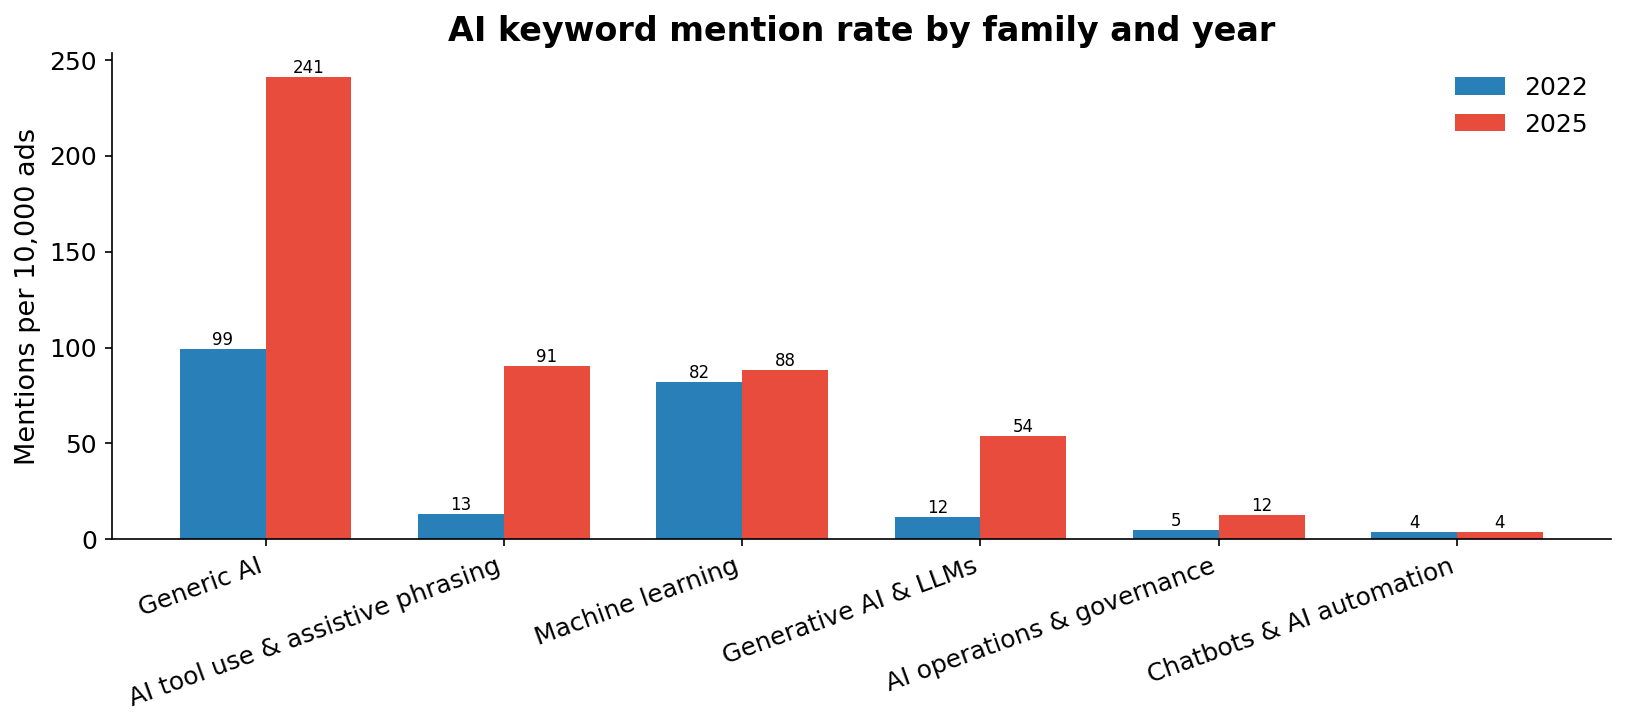

saved /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/pipeline/production_5m/ai_keyword_sweep/figures/rate_by_family_year.png


In [10]:
fam_cols_sql = ",\n    ".join(
    f"1e4 * AVG(hit_{fk}::INT) AS rate_{fk}_per_10k" for fk in FAMILY_KEYS
)
fam_n_sql = ",\n    ".join(
    f"SUM(hit_{fk}::INT) AS n_{fk}" for fk in FAMILY_KEYS
)
rate_by_family_year = con.execute(f"""
  SELECT
    year,
    COUNT(*) AS n,
    {fam_n_sql},
    {fam_cols_sql}
  FROM hits GROUP BY year ORDER BY year
""").fetchdf()
rate_by_family_year.to_csv(ANALYSIS_DIR / "rate_by_family_year.csv", index=False)
# print a tidy reshape
tidy = []
for _, r in rate_by_family_year.iterrows():
    for fk in FAMILY_KEYS:
        tidy.append({
            'year': int(r['year']), 'family': fk,
            'n_hits': int(r[f'n_{fk}']),
            'rate_per_10k': float(r[f'rate_{fk}_per_10k']),
            'n': int(r['n']),
        })
tidy_df = pd.DataFrame(tidy)
print("Rate by family × year (per 10,000):")
print(tidy_df.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

# Side-by-side family rates figure
fig, ax = plt.subplots(figsize=(11, 5))
years = sorted(tidy_df['year'].unique())
x = np.arange(len(FAMILY_KEYS))
w = 0.36
for i, yr in enumerate(years):
    sub = tidy_df[tidy_df['year'] == yr].set_index('family').reindex(FAMILY_KEYS)
    heights = sub['rate_per_10k'].values
    ax.bar(x + (i - 0.5) * w, heights, w, label=str(yr),
           color=SECONDARY if yr == 2022 else ACCENT)
    for xi, h in zip(x, heights):
        ax.text(xi + (i - 0.5) * w, h, f'{h:.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([d.families[fk] for fk in FAMILY_KEYS], rotation=20, ha='right')
ax.set_ylabel('Mentions per 10,000 ads')
ax.set_title('AI keyword mention rate by family and year', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "rate_by_family_year.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"saved {FIG_DIR / 'rate_by_family_year.png'}")

## §8.3 — `rate_by_exposure_decile.csv`

Exposure-decile gradient pooled + within text-length decile. The
within-length variant is the length-confound robustness check (output 7
in the spec uses text-length deciles separately; here we cross with
exposure decile to see the gradient survive length-control).

Pooled exposure-decile gradient:
 exp_decile      n  mean_exposure  rate_any_per_10k  rate_generative_per_10k
          1 499723         0.1084           38.8415                   5.9833
          2 499723         0.2126           33.5986                  12.1267
          3 499723         0.2899           34.6792                  12.2268
          4 499723         0.3604           43.4040                   9.1251
          5 499723         0.4193           73.6008                   9.7254
          6 499723         0.4604          119.1460                  14.7882
          7 499723         0.4794          181.1003                  25.6542
          8 499722         0.4900          255.6221                  31.2574
          9 499722         0.4957          414.4704                  46.6259
         10 499722         0.5000          819.5357                  93.6120


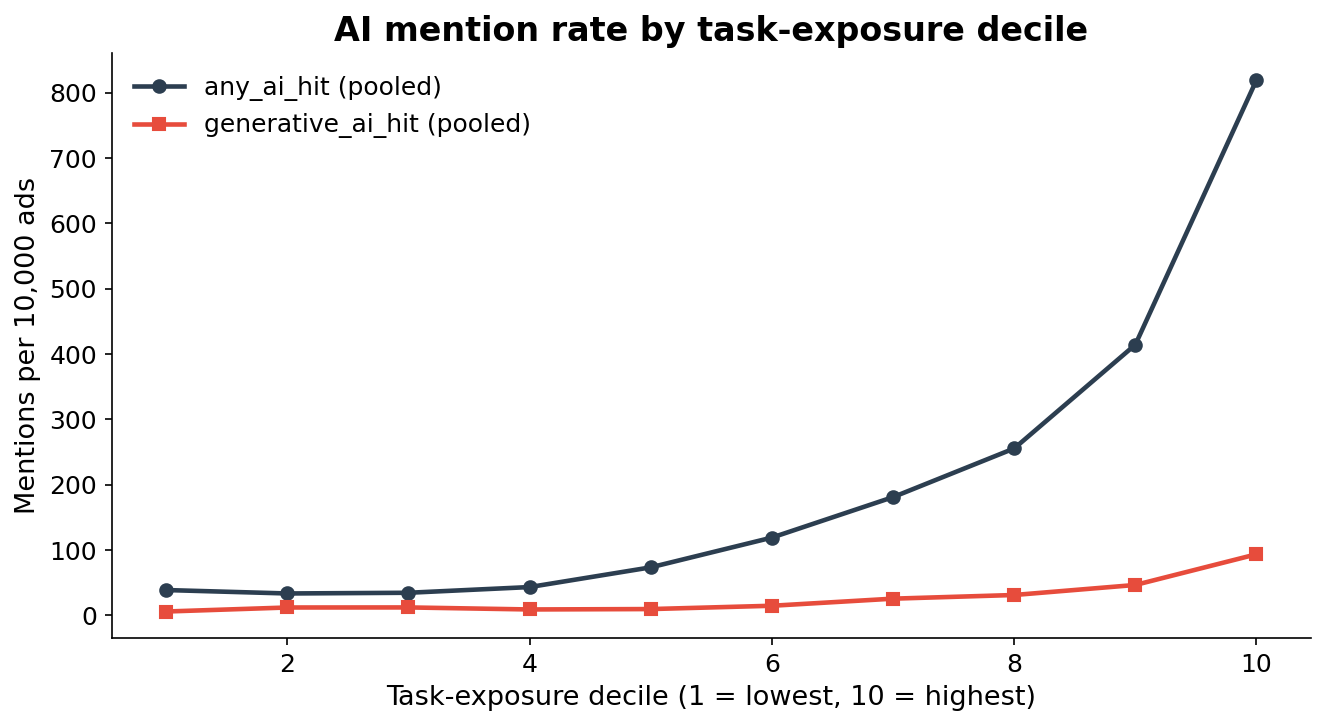

In [11]:
con.execute("""
  CREATE OR REPLACE TABLE _ap_hits AS
  SELECT p.*, h.n_chars, h.n_tokens, h.any_ai_hit, h.generative_ai_hit,
         h.hit_generic_ai, h.hit_ai_tool_use, h.hit_machine_learning,
         h.hit_generative_ai, h.hit_ai_ops_governance, h.hit_chatbot_automation,
         h.n_families_hit, h.n_total_matches
  FROM ad_primary p
  LEFT JOIN hits h ON p.ad_id = h.ad_id
""")
n_joined = con.execute("SELECT COUNT(*) FROM _ap_hits WHERE any_ai_hit IS NOT NULL").fetchone()[0]
assert n_joined == N_ADS_TOTAL, f"join integrity: {n_joined} != {N_ADS_TOTAL}"

# decile of task_exposure_mean, pooled
deciles_pool = con.execute("""
  WITH d AS (
    SELECT *, NTILE(10) OVER (ORDER BY task_exposure_mean) AS exp_decile FROM _ap_hits
  )
  SELECT exp_decile,
         COUNT(*) AS n,
         AVG(task_exposure_mean) AS mean_exposure,
         1e4 * AVG(any_ai_hit::INT) AS rate_any_per_10k,
         1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k
  FROM d GROUP BY exp_decile ORDER BY exp_decile
""").fetchdf()
print("Pooled exposure-decile gradient:")
print(deciles_pool.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# decile of exposure within decile of text length
deciles_within = con.execute("""
  WITH d AS (
    SELECT *,
           NTILE(10) OVER (ORDER BY task_exposure_mean) AS exp_decile,
           NTILE(10) OVER (ORDER BY n_tokens)            AS len_decile
    FROM _ap_hits
  )
  SELECT exp_decile, len_decile,
         COUNT(*) AS n,
         1e4 * AVG(any_ai_hit::INT)      AS rate_any_per_10k,
         1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k
  FROM d GROUP BY exp_decile, len_decile ORDER BY exp_decile, len_decile
""").fetchdf()
rate_by_exposure_decile = deciles_pool.copy()
rate_by_exposure_decile['variant'] = 'pooled'
deciles_within['variant'] = 'within_length_decile'
rate_by_exposure_decile_long = pd.concat([
    rate_by_exposure_decile.assign(len_decile=pd.NA),
    deciles_within,
], ignore_index=True, sort=False)
rate_by_exposure_decile_long.to_csv(ANALYSIS_DIR / "rate_by_exposure_decile.csv", index=False)

# Figure: pooled curve + a few length-decile lines
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(deciles_pool['exp_decile'], deciles_pool['rate_any_per_10k'],
        marker='o', linewidth=2.2, label='any_ai_hit (pooled)', color=PRIMARY)
ax.plot(deciles_pool['exp_decile'], deciles_pool['rate_generative_per_10k'],
        marker='s', linewidth=2.2, label='generative_ai_hit (pooled)', color=ACCENT)
ax.set_xlabel('Task-exposure decile (1 = lowest, 10 = highest)')
ax.set_ylabel('Mentions per 10,000 ads')
ax.set_title('AI mention rate by task-exposure decile', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "rate_by_exposure_decile.png", dpi=300, bbox_inches='tight')
plt.show()

topline_keyword["gradient_endpoints"] = {
    "decile_1": {
        "any":         float(deciles_pool.iloc[0]["rate_any_per_10k"]),
        "generative":  float(deciles_pool.iloc[0]["rate_generative_per_10k"]),
    },
    "decile_10": {
        "any":         float(deciles_pool.iloc[-1]["rate_any_per_10k"]),
        "generative":  float(deciles_pool.iloc[-1]["rate_generative_per_10k"]),
    },
}

## §8.4 — `rate_by_major_group.csv`

Major-group mention rates (per 10,000), pooled, sorted by any_ai_hit:
                      major_group      n  rate_any_per_10k  rate_generative_per_10k  mean_task_exposure_abs
          Computer & Mathematical 466228           1008.67                   121.87                    0.49
  Life, Physical & Social Science  96676            370.10                    29.17                    0.47
       Farming, Fishing, Forestry   4082            357.67                     0.00                    0.23
               Protective Service  33385            322.00                    30.85                    0.30
      Arts, Design, Entertainment  87619            318.65                    48.51                    0.45
             Business & Financial 362533            272.75                    24.85                    0.49
                       Management 696703            203.69                    24.72                    0.48
                            Legal  65224            195.02        

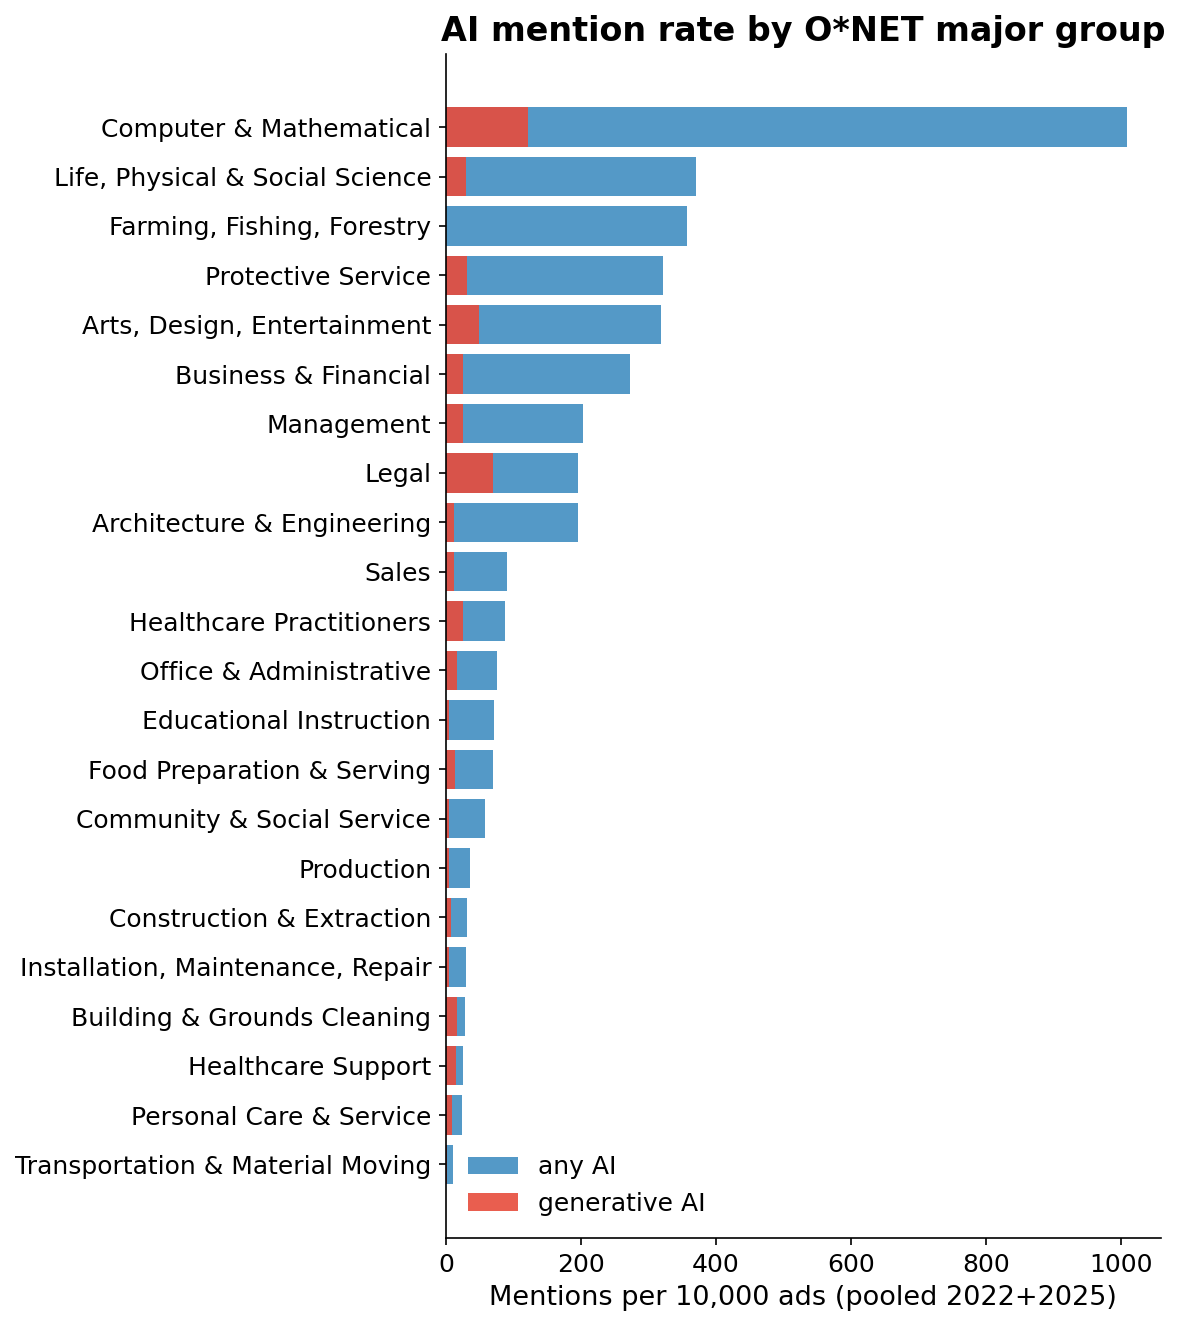

In [12]:
rate_by_major_group = con.execute("""
  SELECT primary_major_code AS major_code,
         year,
         COUNT(*) AS n,
         1e4 * AVG(any_ai_hit::INT) AS rate_any_per_10k,
         1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k,
         AVG(task_exposure_mean) AS mean_task_exposure_abs,
         AVG(task_exposure_bt_mean) AS mean_task_exposure_bt
  FROM _ap_hits
  GROUP BY primary_major_code, year
  ORDER BY primary_major_code, year
""").fetchdf()
rate_by_major_group['major_group'] = rate_by_major_group['major_code'].map(ONET_MAJOR_NAMES)
rate_by_major_group = rate_by_major_group[
    ['major_code', 'major_group', 'year', 'n',
     'rate_any_per_10k', 'rate_generative_per_10k',
     'mean_task_exposure_abs', 'mean_task_exposure_bt']
]
rate_by_major_group.to_csv(ANALYSIS_DIR / "rate_by_major_group.csv", index=False)

# pooled-across-years view, sorted
pooled_major = con.execute("""
  SELECT primary_major_code AS major_code,
         COUNT(*) AS n,
         1e4 * AVG(any_ai_hit::INT) AS rate_any_per_10k,
         1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k,
         AVG(task_exposure_mean) AS mean_task_exposure_abs
  FROM _ap_hits GROUP BY primary_major_code
""").fetchdf()
pooled_major['major_group'] = pooled_major['major_code'].map(ONET_MAJOR_NAMES)
pooled_major = pooled_major.sort_values('rate_any_per_10k', ascending=False)
print("Major-group mention rates (per 10,000), pooled, sorted by any_ai_hit:")
print(pooled_major[['major_group', 'n', 'rate_any_per_10k', 'rate_generative_per_10k',
                    'mean_task_exposure_abs']].to_string(
    index=False, float_format=lambda v: f'{v:.2f}'))

# Figure: horizontal bar
fig, ax = plt.subplots(figsize=(8, 9))
sub = pooled_major.sort_values('rate_any_per_10k')
y = np.arange(len(sub))
ax.barh(y, sub['rate_any_per_10k'], color=SECONDARY, label='any AI', alpha=0.8)
ax.barh(y, sub['rate_generative_per_10k'], color=ACCENT, label='generative AI', alpha=0.9)
ax.set_yticks(y)
ax.set_yticklabels(sub['major_group'])
ax.set_xlabel('Mentions per 10,000 ads (pooled 2022+2025)')
ax.set_title('AI mention rate by O*NET major group', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "rate_by_major_group.png", dpi=300, bbox_inches='tight')
plt.show()

## §8.5 — `rate_by_quadrant.csv`

In [13]:
rate_by_quadrant = con.execute("""
  SELECT quadrant, year,
         COUNT(*) AS n,
         1e4 * AVG(any_ai_hit::INT) AS rate_any_per_10k,
         1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k,
         AVG(task_exposure_mean)    AS mean_exposure,
         AVG(presence_composite)    AS mean_presence
  FROM _ap_hits
  GROUP BY quadrant, year
  ORDER BY quadrant, year
""").fetchdf()
rate_by_quadrant.to_csv(ANALYSIS_DIR / "rate_by_quadrant.csv", index=False)
print("Rate by quadrant × year:")
print(rate_by_quadrant.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

Rate by quadrant × year:
  quadrant  year       n  rate_any_per_10k  rate_generative_per_10k  mean_exposure  mean_presence
 augmented  2022  260525           202.054                   13.972          0.496          0.571
 augmented  2025  121810           548.477                   79.796          0.496          0.573
    middle  2022 2377124           169.385                   12.351          0.414          0.530
    middle  2025 1289811           280.630                   56.125          0.410          0.534
 resilient  2022   32103            27.723                   12.148          0.249          0.579
 resilient  2025   16150           101.548                    1.858          0.247          0.579
 unchanged  2022  505010            15.227                    7.544          0.154          0.455
 unchanged  2025  243975            85.378                    6.599          0.168          0.457
vulnerable  2022  110594           499.846                    6.782          0.497          0

## §8.6 — `rate_by_lad.csv` (with London-vs-rest summary)

In [14]:
rate_by_lad = con.execute("""
  SELECT LAD22CD,
         COUNT(*) AS n,
         1e4 * AVG(any_ai_hit::INT) AS rate_any_per_10k,
         1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k,
         AVG(task_exposure_mean)    AS mean_exposure
  FROM _ap_hits
  WHERE LAD22CD IS NOT NULL
  GROUP BY LAD22CD
""").fetchdf()
# attach LAD22NM
geo = pd.read_csv(GEO_LAD_PATH)[['LAD22CD', 'LAD22NM']]
rate_by_lad = rate_by_lad.merge(geo, on='LAD22CD', how='left')
rate_by_lad['is_london'] = rate_by_lad['LAD22CD'].str.startswith('E09').astype(int)
rate_by_lad = rate_by_lad[
    ['LAD22CD', 'LAD22NM', 'is_london', 'n',
     'rate_any_per_10k', 'rate_generative_per_10k', 'mean_exposure']
].sort_values('rate_any_per_10k', ascending=False)
rate_by_lad.to_csv(ANALYSIS_DIR / "rate_by_lad.csv", index=False)
print("Top 15 LADs by any-AI mention rate (per 10,000):")
print(rate_by_lad.head(15).to_string(index=False, float_format=lambda v: f'{v:.2f}'))

london_summary = con.execute("""
  SELECT
    CASE WHEN LAD22CD LIKE 'E09%%' THEN 'London' ELSE 'Rest of UK' END AS region,
    COUNT(*) AS n,
    1e4 * AVG(any_ai_hit::INT)        AS rate_any_per_10k,
    1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k
  FROM _ap_hits
  WHERE LAD22CD IS NOT NULL
  GROUP BY region
""").fetchdf()
print("\nLondon vs Rest of UK:")
print(london_summary.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

topline_keyword["london_vs_rest"] = {
    row["region"]: {
        "n": int(row["n"]),
        "rate_any_per_10k": float(row["rate_any_per_10k"]),
        "rate_generative_per_10k": float(row["rate_generative_per_10k"]),
    }
    for _, row in london_summary.iterrows()
}

Top 15 LADs by any-AI mention rate (per 10,000):
  LAD22CD              LAD22NM  is_london     n  rate_any_per_10k  rate_generative_per_10k  mean_exposure
E09000001       City of London          1 66349            587.05                    99.93           0.46
E07000243            Stevenage          0  3015            553.90                   102.82           0.42
E09000033          Westminster          1 77259            534.44                    25.63           0.42
E07000008            Cambridge          0  4859            471.29                    22.64           0.39
E09000018             Hounslow          1 10678            451.40                    54.32           0.39
E07000241      Welwyn Hatfield          0 11298            421.31                    12.39           0.38
S12000018           Inverclyde          0  1494            381.53                     0.00           0.35
E07000092             Rushmoor          0  5007            361.49                    21.97           0.

## §8.7 — `rate_by_text_length_decile.csv`

Within-year decile of `n_tokens`. The length confound check: AI-salient
ads may simply be longer.

Mention rate within text-length decile, by year:
 year  len_decile      n  mean_tokens  rate_any_per_10k  rate_generative_per_10k
 2022           1 328536        88.39             27.06                     0.97
 2022           2 328536       169.07             65.65                     4.93
 2022           3 328536       223.96             95.12                     4.63
 2022           4 328536       270.62             95.85                     4.11
 2022           5 328536       315.71             97.83                     7.91
 2022           6 328536       362.82            158.22                    14.52
 2022           7 328535       420.63            119.23                    10.23
 2022           8 328535       494.46            157.79                    10.04
 2022           9 328535       604.60            234.50                    14.12
 2022          10 328535       887.44            528.95                    44.04
 2025           1 171188        96.11             85.64     

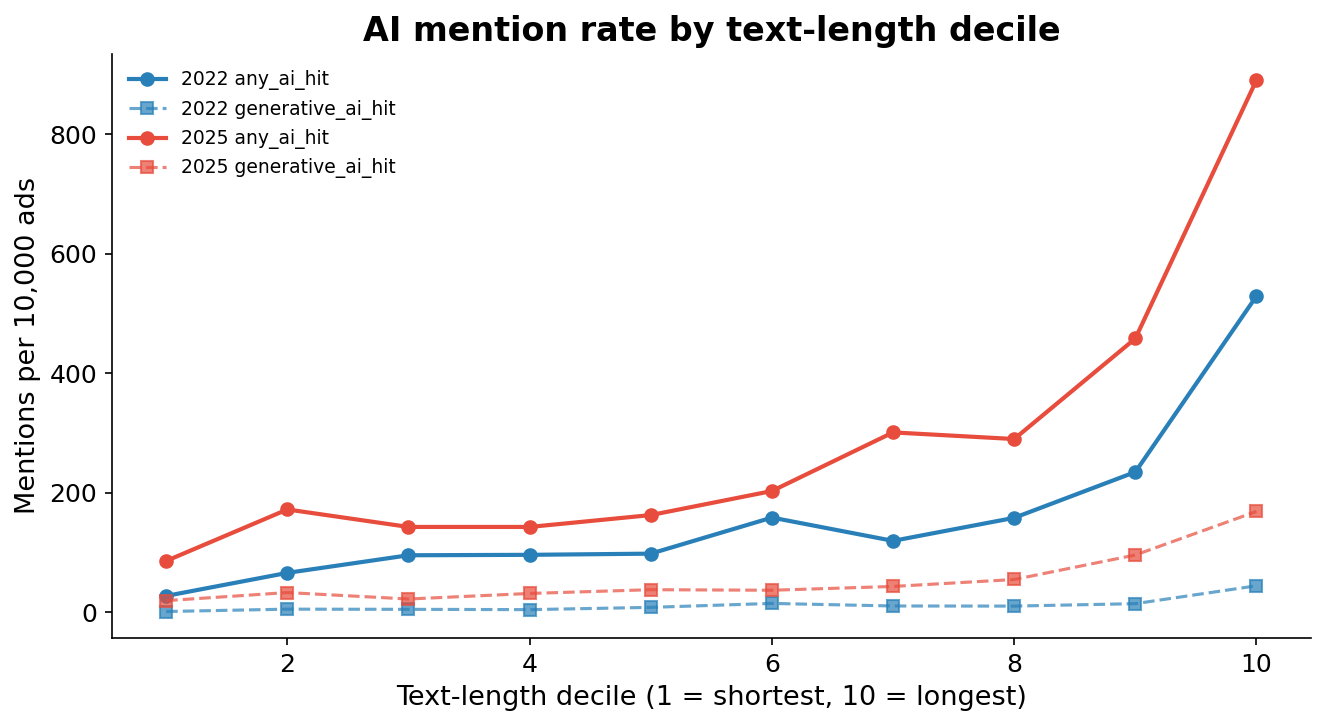

In [15]:
rate_by_text_length_decile = con.execute("""
  WITH d AS (
    SELECT *, NTILE(10) OVER (PARTITION BY year ORDER BY n_tokens) AS len_decile
    FROM _ap_hits
  )
  SELECT year, len_decile,
         COUNT(*) AS n,
         AVG(n_tokens) AS mean_tokens,
         1e4 * AVG(any_ai_hit::INT)        AS rate_any_per_10k,
         1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k
  FROM d GROUP BY year, len_decile ORDER BY year, len_decile
""").fetchdf()
rate_by_text_length_decile.to_csv(ANALYSIS_DIR / "rate_by_text_length_decile.csv", index=False)
print("Mention rate within text-length decile, by year:")
print(rate_by_text_length_decile.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

# Figure
fig, ax = plt.subplots(figsize=(9, 5))
for yr in [2022, 2025]:
    sub = rate_by_text_length_decile[rate_by_text_length_decile['year'] == yr]
    ax.plot(sub['len_decile'], sub['rate_any_per_10k'],
            marker='o', linewidth=2, label=f'{yr} any_ai_hit',
            color=SECONDARY if yr == 2022 else ACCENT)
    ax.plot(sub['len_decile'], sub['rate_generative_per_10k'],
            marker='s', linewidth=1.5, linestyle='--',
            label=f'{yr} generative_ai_hit',
            color=SECONDARY if yr == 2022 else ACCENT,
            alpha=0.7)
ax.set_xlabel('Text-length decile (1 = shortest, 10 = longest)')
ax.set_ylabel('Mentions per 10,000 ads')
ax.set_title('AI mention rate by text-length decile', fontweight='bold')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "rate_by_text_length_decile.png", dpi=300, bbox_inches='tight')
plt.show()

## §8.8 — `exposure_x_demand_occupation.csv` — the 2×2 at occupation level

Aggregate to occupation. Top-quartile by occupation-level mean exposure
AND top-quartile by occupation-level mention rate. Minimum n=100 ads per
occupation so small occupations don't dominate the quartile cutoffs.

In [16]:
occ = con.execute("""
  SELECT primary_onet AS onet_code,
         COUNT(*) AS n,
         AVG(task_exposure_mean) AS mean_exposure,
         AVG(presence_composite) AS mean_presence,
         1e4 * AVG(any_ai_hit::INT)        AS rate_any_per_10k,
         1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k
  FROM _ap_hits
  GROUP BY primary_onet
""").fetchdf()
occ['major_code'] = occ['onet_code'].str[:2].astype(int)
occ['major_group'] = occ['major_code'].map(ONET_MAJOR_NAMES)

# occupation titles
onet_titles = pd.read_csv(ONET_DATA_PATH, sep='\t')[['O*NET-SOC Code', 'Title']]
onet_titles = onet_titles.rename(columns={'O*NET-SOC Code': 'onet_code', 'Title': 'title'})
occ = occ.merge(onet_titles, on='onet_code', how='left')

MIN_N = 100
occ_q = occ[occ['n'] >= MIN_N].copy()
print(f"occupations with n >= {MIN_N}: {len(occ_q)} / {len(occ)}")

exp_q75 = occ_q['mean_exposure'].quantile(0.75)
dem_q75 = occ_q['rate_any_per_10k'].quantile(0.75)
print(f"top-quartile cutoffs: mean_exposure >= {exp_q75:.4f}, rate_any >= {dem_q75:.2f}/10k")
occ_q['exposure_class'] = np.where(occ_q['mean_exposure'] >= exp_q75, 'high_exposure', 'lower_exposure')
occ_q['demand_class'] = np.where(occ_q['rate_any_per_10k'] >= dem_q75, 'high_demand', 'lower_demand')
occ_q['cell'] = occ_q['exposure_class'] + '__' + occ_q['demand_class']

cell_summary = occ_q.groupby('cell').agg(
    n_occupations=('onet_code', 'count'),
    n_ads_total=('n', 'sum'),
    mean_exposure=('mean_exposure', 'mean'),
    mean_rate_any=('rate_any_per_10k', 'mean'),
).reset_index()
print("\nExposure × Demand 2×2 at occupation level (occupations counted):")
print(cell_summary.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

# top-N occupations in each off-diagonal cell
def _top(df, cell, k=15, sort_by='n'):
    return df[df['cell'] == cell].sort_values(sort_by, ascending=False).head(k)[
        ['onet_code', 'title', 'major_group', 'n',
         'mean_exposure', 'rate_any_per_10k', 'rate_generative_per_10k']
    ]

latent_cell = 'high_exposure__lower_demand'
active_cell = 'high_exposure__high_demand'
print(f"\nLATENT (high exposure, low demand) — top {15} by ad count:")
print(_top(occ_q, latent_cell, 15).to_string(index=False, float_format=lambda v: f'{v:.2f}'))
print(f"\nACTIVE (high exposure, high demand) — top {15} by ad count:")
print(_top(occ_q, active_cell, 15).to_string(index=False, float_format=lambda v: f'{v:.2f}'))

occ_q.to_csv(ANALYSIS_DIR / "exposure_x_demand_occupation.csv", index=False)
cell_summary.to_csv(ANALYSIS_DIR / "exposure_x_demand_occupation_cells.csv", index=False)

topline_keyword["exposure_x_demand_occupation"] = {
    "min_n_per_occupation": MIN_N,
    "exposure_q75": float(exp_q75),
    "demand_q75_any_per_10k": float(dem_q75),
    "cell_sizes": {
        row["cell"]: {
            "n_occupations": int(row["n_occupations"]),
            "n_ads_total": int(row["n_ads_total"]),
        }
        for _, row in cell_summary.iterrows()
    },
}

occupations with n >= 100: 798 / 861
top-quartile cutoffs: mean_exposure >= 0.4701, rate_any >= 186.69/10k

Exposure × Demand 2×2 at occupation level (occupations counted):
                        cell  n_occupations  n_ads_total  mean_exposure  mean_rate_any
  high_exposure__high_demand            117      1077327          0.486        889.511
 high_exposure__lower_demand             83       902068          0.482         90.150
 lower_exposure__high_demand             83       167733          0.392        465.380
lower_exposure__lower_demand            515      2846845          0.295         44.894

LATENT (high exposure, low demand) — top 15 by ad count:
 onet_code                                                                           title                major_group     n  mean_exposure  rate_any_per_10k  rate_generative_per_10k
43-6014.00 Secretaries and Administrative Assistants, Except Legal, Medical, and Executive    Office & Administrative 66383           0.47             7

## §8.9 — `exposure_x_demand_lad.csv` — same 2×2 at LAD level

In [17]:
lad = con.execute("""
  SELECT LAD22CD,
         COUNT(*) AS n,
         AVG(task_exposure_mean) AS mean_exposure,
         1e4 * AVG(any_ai_hit::INT)        AS rate_any_per_10k,
         1e4 * AVG(generative_ai_hit::INT) AS rate_generative_per_10k
  FROM _ap_hits
  WHERE LAD22CD IS NOT NULL
  GROUP BY LAD22CD
""").fetchdf()
lad = lad.merge(geo, on='LAD22CD', how='left')
lad['is_london'] = lad['LAD22CD'].str.startswith('E09').astype(int)

MIN_N_LAD = 500
lad_q = lad[lad['n'] >= MIN_N_LAD].copy()
print(f"LADs with n >= {MIN_N_LAD}: {len(lad_q)} / {len(lad)}")

lad_exp_q75 = lad_q['mean_exposure'].quantile(0.75)
lad_dem_q75 = lad_q['rate_any_per_10k'].quantile(0.75)
print(f"LAD cutoffs: mean_exposure >= {lad_exp_q75:.4f}, rate_any >= {lad_dem_q75:.2f}/10k")
lad_q['exposure_class'] = np.where(lad_q['mean_exposure'] >= lad_exp_q75, 'high_exposure', 'lower_exposure')
lad_q['demand_class'] = np.where(lad_q['rate_any_per_10k'] >= lad_dem_q75, 'high_demand', 'lower_demand')
lad_q['cell'] = lad_q['exposure_class'] + '__' + lad_q['demand_class']

lad_cell_summary = lad_q.groupby('cell').agg(
    n_lads=('LAD22CD', 'count'),
    n_ads_total=('n', 'sum'),
    mean_exposure=('mean_exposure', 'mean'),
    mean_rate_any=('rate_any_per_10k', 'mean'),
).reset_index()
print("\nLAD-level 2×2:")
print(lad_cell_summary.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

print("\nLATENT LADs (high exposure, low demand):")
print(lad_q[lad_q['cell'] == 'high_exposure__lower_demand']
      .sort_values('n', ascending=False).head(15)[
          ['LAD22CD', 'LAD22NM', 'is_london', 'n',
           'mean_exposure', 'rate_any_per_10k']
      ].to_string(index=False, float_format=lambda v: f'{v:.2f}'))

print("\nACTIVE LADs (high exposure, high demand):")
print(lad_q[lad_q['cell'] == 'high_exposure__high_demand']
      .sort_values('n', ascending=False).head(15)[
          ['LAD22CD', 'LAD22NM', 'is_london', 'n',
           'mean_exposure', 'rate_any_per_10k']
      ].to_string(index=False, float_format=lambda v: f'{v:.2f}'))

lad_q.to_csv(ANALYSIS_DIR / "exposure_x_demand_lad.csv", index=False)
lad_cell_summary.to_csv(ANALYSIS_DIR / "exposure_x_demand_lad_cells.csv", index=False)

topline_keyword["exposure_x_demand_lad"] = {
    "min_n_per_lad": MIN_N_LAD,
    "exposure_q75": float(lad_exp_q75),
    "demand_q75_any_per_10k": float(lad_dem_q75),
    "cell_sizes": {
        row["cell"]: {
            "n_lads": int(row["n_lads"]),
            "n_ads_total": int(row["n_ads_total"]),
        }
        for _, row in lad_cell_summary.iterrows()
    },
}

LADs with n >= 500: 370 / 373
LAD cutoffs: mean_exposure >= 0.3679, rate_any >= 129.22/10k

LAD-level 2×2:
                        cell  n_lads  n_ads_total  mean_exposure  mean_rate_any
  high_exposure__high_demand      58      1162263          0.391        250.143
 high_exposure__lower_demand      35       301447          0.376         87.833
 lower_exposure__high_demand      35       296978          0.350        177.994
lower_exposure__lower_demand     242      1542538          0.340         54.902

LATENT LADs (high exposure, low demand):
  LAD22CD               LAD22NM  is_london     n  mean_exposure  rate_any_per_10k
E08000027                Dudley          0 18616           0.38             66.61
E08000032              Bradford          0 17616           0.37            114.10
E09000008               Croydon          1 16898           0.39             65.69
E07000084 Basingstoke and Deane          0 16860           0.38            114.47
E09000017            Hillingdon          

## §9 — Full 8-step QC + audit samples

1. Boundary audit (short tokens).
2. Recall spot-check (non-matching ads).
3. Per-family precision sample.
4. Denominator sanity.
5. Quadrant equality (run already in §6).
6. Join integrity (run already in §8.3).
7. Length-confound (run already in §8.7).
8. Regex equivalence (run already in §7a).

Audit samples are written to `audit_samples/` with deterministic
`ad_id`-hashed selection. Samples carry the matched terms so a reviewer
can read them without re-running the matcher.

In [18]:
def _audit_by_hits_pred(pred: str, name: str, salt: str, k: int = 50) -> pd.DataFrame:
    """Deterministic sample of ads where `pred` holds on `hits`; joins to
    the pre-extracted ad_text parquet to materialise text columns."""
    sql = f"""
      WITH _picked AS (
        SELECT ad_id FROM hits WHERE {pred}
        ORDER BY md5(CAST(ad_id AS VARCHAR) || ?) LIMIT {k}
      )
      SELECT h.*, t.title, t.description
      FROM _picked p
      JOIN hits h ON h.ad_id = p.ad_id
      JOIN ad_text t ON t.ad_id = p.ad_id
    """
    df = con.execute(sql, [salt]).fetchdf()
    df.to_csv(AUDIT_DIR / f"{name}.csv", index=False)
    return df


def _audit_by_term_regex(token: str, pattern: str, family_hit_col: str,
                         name: str, salt: str, k: int = 20) -> pd.DataFrame:
    """Sample ads where the literal short-token pattern matches the text.

    Restricts to ads where the family containing the token already fired
    (≤100k rows, not 5M), then runs the per-token regex on text from the
    pre-extracted ad_text parquet.
    """
    sql = f"""
      WITH _candidates AS (
        SELECT h.ad_id FROM hits h WHERE h.{family_hit_col} = TRUE
      ),
      _picked AS (
        SELECT t.ad_id
        FROM ad_text t
        JOIN _candidates c ON c.ad_id = t.ad_id
        WHERE regexp_matches(
          lower(coalesce(t.title, '') || ' ' || coalesce(t.description, '')),
          ?
        )
        ORDER BY md5(CAST(t.ad_id AS VARCHAR) || ?)
        LIMIT {k}
      )
      SELECT
        h.ad_id, h.year, h.n_chars, h.n_tokens, h.n_total_matches,
        h.any_ai_hit, h.generative_ai_hit,
        h.hit_generic_ai, h.hit_ai_tool_use, h.hit_machine_learning,
        h.hit_generative_ai, h.hit_ai_ops_governance, h.hit_chatbot_automation,
        t.title, t.description,
        ? AS audited_token
      FROM _picked p
      JOIN hits h ON h.ad_id = p.ad_id
      JOIN ad_text t ON t.ad_id = p.ad_id
    """
    df = con.execute(sql, [pattern, salt, token]).fetchdf()
    df.to_csv(AUDIT_DIR / f"{name}.csv", index=False)
    return df


# --- QC1: boundary audit per short-token -----------------------------
# Each short token sits in exactly one family in v1; that family's hit
# flag is a superset of the token's matches, so we filter on it first.
print("\n=== QC1: short-token false-positive audit ===")
SHORT_TOKEN_SPEC = [
    # (token, regex, family_hit_column)
    ("ai",  r"\bai\b",  "hit_generic_ai"),
    ("ml",  r"\bml\b",  "hit_machine_learning"),
    ("llm", r"\bllm\b", "hit_generative_ai"),
    ("nlp", r"\bnlp\b", "hit_machine_learning"),
    ("rag", r"\brag\b", "hit_generative_ai"),
    ("xai", r"\bxai\b", "hit_ai_ops_governance"),
    ("gpt", r"\bgpt\b", "hit_generative_ai"),
]
for tok, pat, family_col in SHORT_TOKEN_SPEC:
    t0 = time.time()
    df = _audit_by_term_regex(
        token=tok, pattern=pat, family_hit_col=family_col,
        name=f"qc1_boundary_{tok}", salt=f"qc1_{tok}", k=20,
    )
    dt = time.time() - t0
    print(f"  {tok:4s} ({family_col}): {len(df)} sampled ads in {dt:.1f}s → "
          f"audit_samples/qc1_boundary_{tok}.csv")

# --- QC2: recall spot-check (non-matching ads) -----------------------
print("\n=== QC2: recall spot-check (non-matching ads) ===")
recall = _audit_by_hits_pred(
    pred="NOT any_ai_hit", name="qc2_recall_nonmatches",
    salt="qc2_recall", k=50,
)
print(f"  sampled {len(recall)} non-matching ads → audit_samples/qc2_recall_nonmatches.csv")

# --- QC3: per-family precision sample --------------------------------
print("\n=== QC3: per-family precision sample ===")
for fk in FAMILY_KEYS:
    df = _audit_by_hits_pred(
        pred=f"hit_{fk}", name=f"qc3_precision_{fk}",
        salt=f"qc3_{fk}", k=30,
    )
    print(f"  {fk:22s}: {len(df)} sampled hits → audit_samples/qc3_precision_{fk}.csv")

# --- QC4: denominator sanity ---------------------------------------
print("\n=== QC4: denominator sanity ===")
qc4 = {
    "n_ads_total_in_hits": int(con.execute("SELECT COUNT(*) FROM hits").fetchone()[0]),
    "n_ads_2022_in_hits": int(con.execute("SELECT COUNT(*) FROM hits WHERE year = 2022").fetchone()[0]),
    "n_ads_2025_in_hits": int(con.execute("SELECT COUNT(*) FROM hits WHERE year = 2025").fetchone()[0]),
    "n_ads_total_in_spine": int(con.execute("SELECT COUNT(*) FROM ad_primary").fetchone()[0]),
    "n_ads_topline_v1_total": int(N_ADS_TOTAL),
    "n_ads_topline_v1_2022":  int(N_ADS_2022),
    "n_ads_topline_v1_2025":  int(N_ADS_2025),
}
for k, v in qc4.items():
    print(f"  {k:32s} = {v:,}")
assert qc4["n_ads_total_in_hits"] == qc4["n_ads_topline_v1_total"]
assert qc4["n_ads_2022_in_hits"]  == qc4["n_ads_topline_v1_2022"]
assert qc4["n_ads_2025_in_hits"]  == qc4["n_ads_topline_v1_2025"]
print("✓ denominators match topline v1")

# QC5, 6, 7, 8 already executed earlier; record their statuses.
topline_keyword["qc"] = {
    "qc1_short_token_audit": "samples in audit_samples/qc1_*.csv (visual review required)",
    "qc2_recall_spot_check": "audit_samples/qc2_recall_nonmatches.csv (visual review required)",
    "qc3_per_family_precision": "audit_samples/qc3_precision_*.csv (visual review required)",
    "qc4_denominator_sanity": "PASS",
    "qc5_quadrant_equality": "PASS",
    "qc6_join_integrity": "PASS",
    "qc7_length_confound": "see rate_by_text_length_decile.csv",
    "qc8_regex_equivalence": "PASS",
}


=== QC1: short-token false-positive audit ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ai   (hit_generic_ai): 20 sampled ads in 6.0s → audit_samples/qc1_boundary_ai.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ml   (hit_machine_learning): 20 sampled ads in 4.2s → audit_samples/qc1_boundary_ml.csv


...

  generative_ai         : 30 sampled hits → audit_samples/qc3_precision_generative_ai.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ai_ops_governance     : 30 sampled hits → audit_samples/qc3_precision_ai_ops_governance.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  chatbot_automation    : 30 sampled hits → audit_samples/qc3_precision_chatbot_automation.csv

=== QC4: denominator sanity ===
  n_ads_total_in_hits              = 4,997,227
  n_ads_2022_in_hits               = 3,285,356
  n_ads_2025_in_hits               = 1,711,871
  n_ads_total_in_spine             = 4,997,227
  n_ads_topline_v1_total           = 4,997,227
  n_ads_topline_v1_2022            = 3,285,356
  n_ads_topline_v1_2025            = 1,711,871
✓ denominators match topline v1


## §10 — Outputs and meta JSON

In [19]:
# Headline figure: panel of (a) family×year rates, (b) exposure-decile gradient,
# (c) length-decile gradient. Already produced as separate files; build a
# stitched composite for the report.

# Manifest
manifest_rows = []
for p in sorted(SWEEP_DIR.rglob("*")):
    if p.is_file() and p.name != "ai_keyword_sweep_v1_meta.json":
        rel = p.relative_to(SWEEP_DIR)
        manifest_rows.append({
            "path": str(rel),
            "size_bytes": p.stat().st_size,
            "modified": datetime.fromtimestamp(p.stat().st_mtime, tz=timezone.utc).isoformat(timespec='seconds'),
        })
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(MANIFEST_PATH, index=False)
print(f"manifest: {len(manifest_df)} files → {MANIFEST_PATH.relative_to(ROOT)}")

# topline_keyword_numbers.json
TOPLINE_KEYWORD_PATH.write_text(json.dumps(topline_keyword, indent=2, sort_keys=False))
print(f"topline_keyword_numbers.json → {TOPLINE_KEYWORD_PATH.relative_to(ROOT)}")

# Meta JSON (last)
input_meta = {}
for label, p in {
    "ad_exposure_parquet": AD_EXPOSURE_PATH,
    "rerank_parquet":      RERANK_PATH,
    "adzuna_db":           ADZUNA_DB_PATH,
    "dictionary_toml":     DICT_PATH,
    "topline_numbers_v1":  TOPLINE_JSON_PATH,
    "quadrant_counts_v1":  QUAD_COUNTS_PATH,
}.items():
    st = p.stat()
    input_meta[label] = {
        "path": str(p.relative_to(ROOT)),
        "size_bytes": st.st_size,
        "modified": datetime.fromtimestamp(st.st_mtime, tz=timezone.utc).isoformat(timespec='seconds'),
    }

meta = {
    "version": "v1",
    "dictionary_version": DICTIONARY_VERSION,
    "run_name": "production_5m",
    "executed_at": datetime.now(timezone.utc).isoformat(timespec='seconds'),
    "ad_counts": qc4,
    "inputs": input_meta,
    "outputs": {
        "per_ad_parquet": str(HITS_PATH.relative_to(ROOT)),
        "analysis_dir":   str(ANALYSIS_DIR.relative_to(ROOT)),
        "audit_dir":      str(AUDIT_DIR.relative_to(ROOT)),
        "figures_dir":    str(FIG_DIR.relative_to(ROOT)),
        "manifest_csv":   str(MANIFEST_PATH.relative_to(ROOT)),
        "topline_json":   str(TOPLINE_KEYWORD_PATH.relative_to(ROOT)),
    },
    "qc_results": topline_keyword["qc"],
}
META_PATH.write_text(json.dumps(meta, indent=2))
print(f"meta JSON → {META_PATH.relative_to(ROOT)}")
print("\n✓ AI keyword sweep complete.")

manifest: 34 files → store/pipeline/production_5m/ai_keyword_sweep/keyword_sweep_manifest.csv
topline_keyword_numbers.json → store/pipeline/production_5m/ai_keyword_sweep/analysis/topline_keyword_numbers.json
meta JSON → store/pipeline/production_5m/ai_keyword_sweep/ai_keyword_sweep_v1_meta.json

✓ AI keyword sweep complete.
